# 14 · How sure is the model? — uncertainty quantification

A model that only outputs a **single number** is dangerous: it never tells you
where it is guessing. Here we make every prediction come with an **honest
confidence**, three ways, and then **check that the confidence is calibrated**.

### 🎯 What you'll learn
1. **Deep ensembles** — train several models; their spread is uncertainty.
2. **Random-forest variance** — the trees already disagree; use it.
3. **MC-dropout** — keep dropout on at inference for a neural estimate.
4. **Calibration** — does a "95%" interval actually contain the truth 95% of the time?

### 🧭 What you need to know first
Notebooks **01** (features) and **03** (random forests). That's enough.

In [1]:
# --- setup: find the repo (auto-clone on Colab), load helpers ---
import os, sys, subprocess
def _find_src():
    for p in ("../src","src","mecanano-ml-nanomechanics/src"):
        if os.path.isdir(p): return p
    return None
if _find_src() is None:
    subprocess.run(["git","clone","--depth","1",
        "https://github.com/edrossi93/mecanano-ml-nanomechanics.git"], check=False)
sys.path.insert(0, os.path.abspath(_find_src() or "mecanano-ml-nanomechanics/src"))
import numpy as np, matplotlib.pyplot as plt
import mecanano_ml as mm
mm.set_style()

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
rng = np.random.default_rng(0)

## 1 · The problem — a point prediction hides its confidence
We predict hardness `H` from the other per-indent channels on the AFM grid. A single model gives one number per indent — and no idea how much to trust it.

In [3]:
afm = mm.load_afm_grid()
feat = ["E","HE","S2P","phase_angle"]
X = np.column_stack([afm[k] for k in feat]); y = afm["H"]
ok = np.isfinite(X).all(1) & np.isfinite(y)
X, y, XY = X[ok], y[ok], (afm["X"][ok], afm["Y"][ok])
Xtr, Xte, ytr, yte, itr, ite = train_test_split(X, y, np.arange(len(y)), test_size=0.35, random_state=0)
sc = StandardScaler().fit(Xtr); Xtr_s, Xte_s = sc.transform(Xtr), sc.transform(Xte)
print(f"{len(X)} indents · features {feat} · predicting H (GPa)")

828 indents · features ['E', 'HE', 'S2P', 'phase_angle'] · predicting H (GPa)


## 2 · Deep ensembles — train several, read their spread
Train **K** small networks from different random seeds. The **mean** is the prediction; the **standard deviation** across the K models is the uncertainty.

ensemble ready; mean uncertainty σ = 0.095 GPa


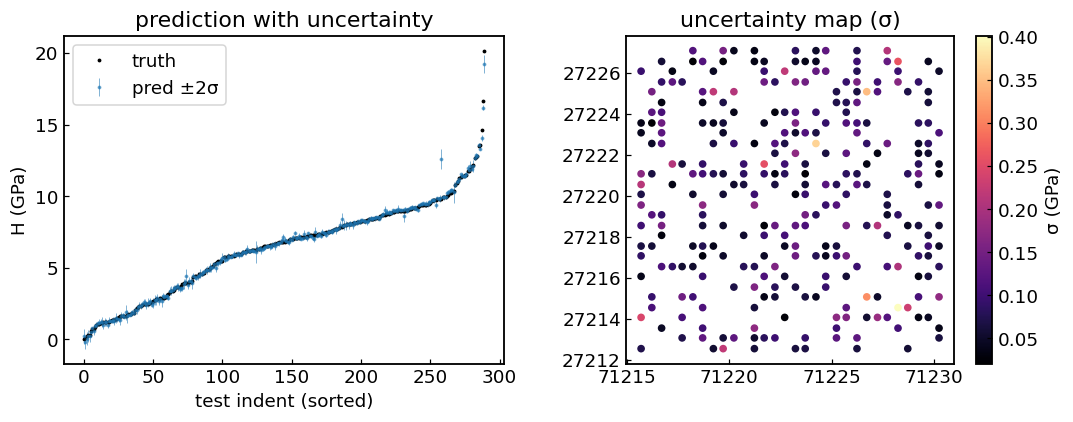

In [4]:
K = 8
preds = np.stack([
    MLPRegressor(hidden_layer_sizes=(32,32), max_iter=400, random_state=s).fit(Xtr_s, ytr).predict(Xte_s)
    for s in range(K)])
mean_e, std_e = preds.mean(0), preds.std(0)
print("ensemble ready; mean uncertainty σ =", round(float(std_e.mean()),3), "GPa")
fig, ax = plt.subplots(1,2, figsize=(10,4))
o = np.argsort(yte)
ax[0].errorbar(np.arange(len(yte)), mean_e[o], yerr=2*std_e[o], fmt=".", ms=3, elinewidth=.6, alpha=.6, label="pred ±2σ")
ax[0].plot(np.arange(len(yte)), yte[o], "k.", ms=3, label="truth")
ax[0].set_xlabel("test indent (sorted)"); ax[0].set_ylabel("H (GPa)"); ax[0].legend(); ax[0].set_title("prediction with uncertainty")
s2 = ax[1].scatter(XY[0][ite], XY[1][ite], c=std_e, s=16, cmap="magma")
ax[1].set_aspect("equal"); ax[1].set_title("uncertainty map (σ)"); plt.colorbar(s2, ax=ax[1], label="σ (GPa)")
fig.tight_layout()

## 3 · Random forests already carry uncertainty
A forest is many trees. Their **disagreement** on a given indent is a free uncertainty estimate — no extra models to train.

RF mean tree σ = 0.49 GPa


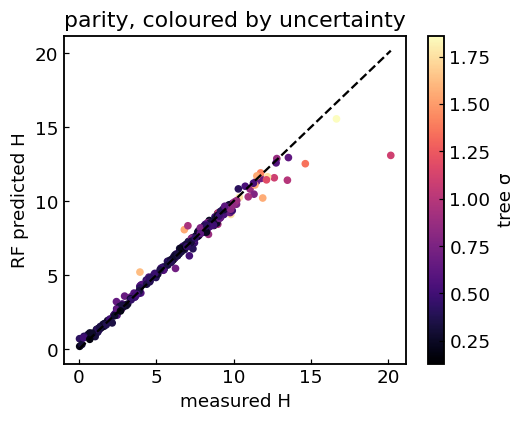

In [5]:
rf = RandomForestRegressor(300, random_state=0, n_jobs=-1).fit(Xtr, ytr)
per_tree = np.stack([t.predict(Xte) for t in rf.estimators_])
mean_rf, std_rf = per_tree.mean(0), per_tree.std(0)
fig, ax = plt.subplots(figsize=(5,4))
sc3 = ax.scatter(yte, mean_rf, c=std_rf, s=16, cmap="magma"); lim=[yte.min(),yte.max()]
ax.plot(lim, lim, "k--"); ax.set_xlabel("measured H"); ax.set_ylabel("RF predicted H")
plt.colorbar(sc3, label="tree σ"); ax.set_title("parity, coloured by uncertainty"); fig.tight_layout()
print("RF mean tree σ =", round(float(std_rf.mean()),3), "GPa")

## 4 · MC-dropout (neural) — *optional, needs PyTorch*

Keep **dropout active at inference** and run the network many times: each pass
drops different units, so you get a *distribution* of predictions. This cell
runs when PyTorch is installed (it is in this repo's environment); otherwise it
skips.

In [6]:
try:
    import torch, torch.nn as nn
    torch.manual_seed(0)
    Xt = torch.tensor(Xtr_s, dtype=torch.float32); yt = torch.tensor(ytr[:,None], dtype=torch.float32)
    net = nn.Sequential(nn.Linear(X.shape[1],32), nn.ReLU(), nn.Dropout(0.2),
                        nn.Linear(32,32), nn.ReLU(), nn.Dropout(0.2), nn.Linear(32,1))
    opt = torch.optim.Adam(net.parameters(), 1e-2); lossf = nn.MSELoss()
    for _ in range(300):
        opt.zero_grad(); lossf(net(Xt), yt).backward(); opt.step()
    net.train()                      # <-- keep dropout ON at inference
    Xe = torch.tensor(Xte_s, dtype=torch.float32)
    with torch.no_grad():
        mc = np.stack([net(Xe).numpy().ravel() for _ in range(50)])
    mean_mc, std_mc = mc.mean(0), mc.std(0)
    print("MC-dropout mean σ =", round(float(std_mc.mean()),3), "GPa (50 stochastic passes)")
except Exception as e:
    print("PyTorch not available — skipping MC-dropout:", type(e).__name__)
    mean_mc = std_mc = None

PyTorch not available — skipping MC-dropout: ModuleNotFoundError


## 5 · Is the uncertainty **calibrated**?

A σ is only useful if it is honest. For a well-calibrated Gaussian estimate,
about **95%** of the true values should fall inside **mean ± 2σ**. We check the
coverage of each method.

method            coverage(±2σ)   target 0.95
  deep ensemble    0.86
  random forest    0.99


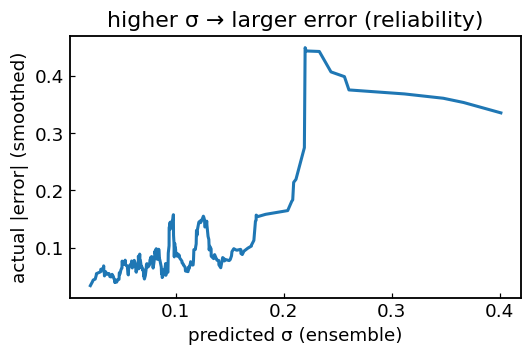

In [7]:
def coverage(mean, std, truth, k=2):
    return float(np.mean(np.abs(truth-mean) <= k*std))
rows = [("deep ensemble", mean_e, std_e), ("random forest", mean_rf, std_rf)]
if std_mc is not None: rows.append(("MC-dropout", mean_mc, std_mc))
print("method            coverage(±2σ)   target 0.95")
for name, m, s in rows:
    print(f"  {name:16s} {coverage(m,s,yte):.2f}")
# reliability: sort by uncertainty, error should grow with predicted σ
fig, ax = plt.subplots(figsize=(5,3.4))
q = np.argsort(std_e); err = np.abs(mean_e-yte)
ax.plot(std_e[q], np.convolve(err[q], np.ones(15)/15, "same"), lw=2)
ax.set_xlabel("predicted σ (ensemble)"); ax.set_ylabel("actual |error| (smoothed)")
ax.set_title("higher σ → larger error (reliability)"); fig.tight_layout()

## ✅ Recap
- **Deep ensembles** and **random-forest tree variance** give uncertainty with no
  new machinery; **MC-dropout** is the neural-network version.
- Always **check calibration**: a "95%" band that only covers 60% is lying.
- On a map, plot the **σ field** — it tells you *where* to trust the model and
  where to measure more (a natural cue for adaptive / operando mapping).

## 🔧 Try it yourself
1. Predict **E** instead of H — is it more or less certain than H?
2. Raise the MC-dropout rate to 0.4 — coverage up or down?
3. Flag the **top-5% most uncertain** indents and overlay them on the map.

## 🩹 Common errors & fixes
- *MC-dropout gives no spread* → you forgot `net.train()` at inference (dropout was off).
- *Coverage ≈ 1.0 everywhere* → σ is over-inflated; reduce dropout / ensemble spread.
- *Shape error after editing* → restart the kernel and run top-to-bottom.